## Load Dataset

In [3]:
!pip install kaggle

In [6]:
 from google.colab import files

In [7]:
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"aliakbar138118","key":"e0d6ee58e94f04da2990ade3816d21e2"}'}

In [9]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [10]:
!kaggle datasets download ruhulaminsharif/eye-disease-image-dataset

Dataset URL: https://www.kaggle.com/datasets/ruhulaminsharif/eye-disease-image-dataset
License(s): Attribution 4.0 International (CC BY 4.0)


In [11]:
!unzip eye-disease-image-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Original Dataset/Original Dataset/Diabetic Retinopathy/DR1209.jpg  
  inflating: Original Dataset/Original Dataset/Diabetic Retinopathy/DR121.jpg  
  inflating: Original Dataset/Original Dataset/Diabetic Retinopathy/DR1210.jpg  
  inflating: Original Dataset/Original Dataset/Diabetic Retinopathy/DR1211.jpg  
  inflating: Original Dataset/Original Dataset/Diabetic Retinopathy/DR1212.jpg  
  inflating: Original Dataset/Original Dataset/Diabetic Retinopathy/DR1213.jpg  
  inflating: Original Dataset/Original Dataset/Diabetic Retinopathy/DR1214.jpg  
  inflating: Original Dataset/Original Dataset/Diabetic Retinopathy/DR1215.jpg  
  inflating: Original Dataset/Original Dataset/Diabetic Retinopathy/DR1216.jpg  
  inflating: Original Dataset/Original Dataset/Diabetic Retinopathy/DR1217.jpg  
  inflating: Original Dataset/Original Dataset/Diabetic Retinopathy/DR1218.jpg  
  inflating: Original Dataset/Original Dataset/Diabetic Ret

In [17]:
from tensorflow.keras.utils import image_dataset_from_directory
import matplotlib.pyplot as plt

In [28]:
train = image_dataset_from_directory('/content/Augmented Dataset/Augmented Dataset', subset='training', validation_split=.2, seed=42)
valid = image_dataset_from_directory('/content/Augmented Dataset/Augmented Dataset', subset='validation', validation_split=.2, seed=42)

Found 16242 files belonging to 10 classes.
Using 12994 files for training.
Found 16242 files belonging to 10 classes.
Using 3248 files for validation.


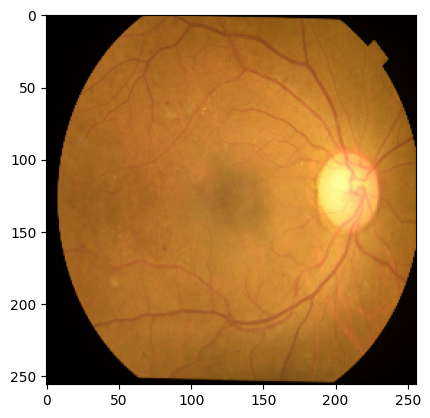

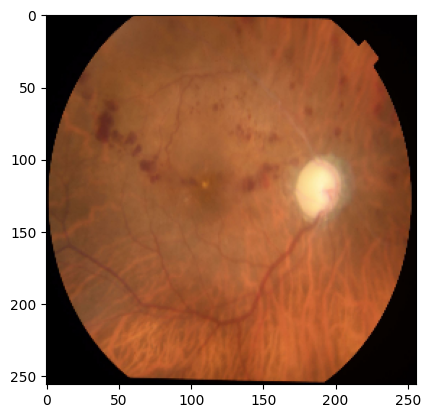

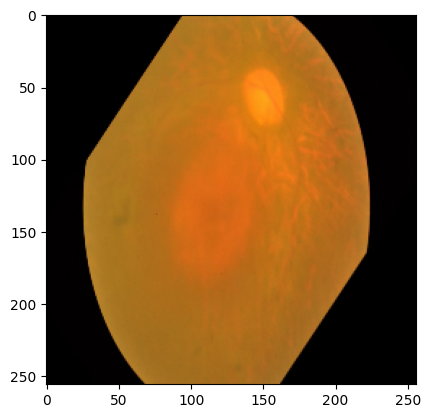

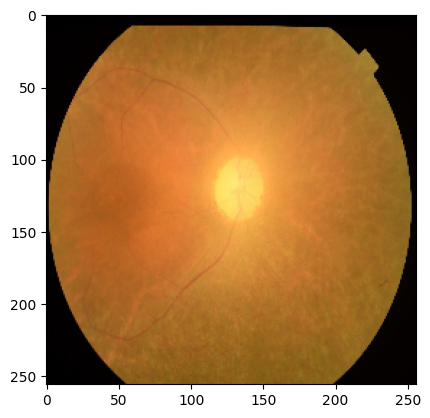

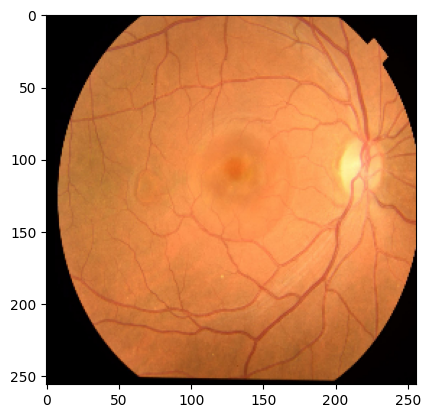

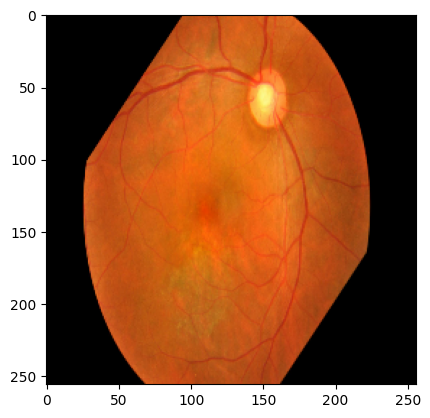

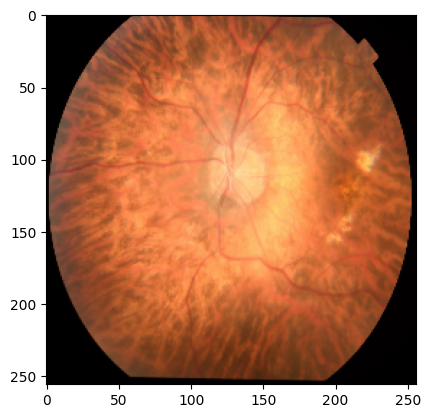

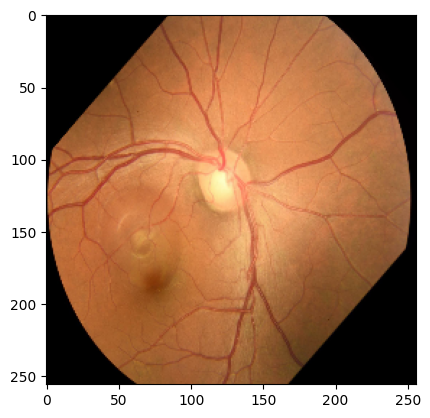

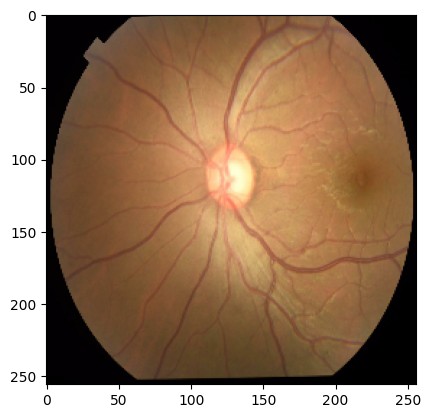

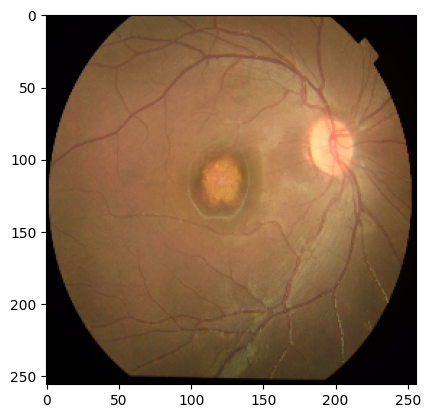

In [29]:
for image, label in train.take(1):
  for i in range(10):
    plt.imshow(image[i].numpy().astype(int))
    plt.show()

In [35]:
def img2img(img, y):
  return img, img

train = train.map(img2img).prefetch(tf.data.AUTOTUNE).cache()
valid = valid.map(img2img).prefetch(tf.data.AUTOTUNE).cache()

## Modeling

In [33]:
import tensorflow as tf
from tensorflow.keras import layers, Model

def unet(input_shape=(128, 128, 3), num_classes=1):
    inputs = tf.keras.Input(shape=input_shape)

    # Encoder (Downsampling path)
    conv1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    conv1 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(conv1)
    pool1 = layers.MaxPooling2D((2, 2))(conv1)

    conv2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(pool1)
    conv2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(conv2)
    pool2 = layers.MaxPooling2D((2, 2))(conv2)

    conv3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(pool2)
    conv3 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(conv3)
    pool3 = layers.MaxPooling2D((2, 2))(conv3)

    conv4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(pool3)
    conv4 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(conv4)
    pool4 = layers.MaxPooling2D((2, 2))(conv4)

    # Bottleneck
    conv5 = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(pool4)
    conv5 = layers.Conv2D(1024, (3, 3), activation='relu', padding='same')(conv5)

    # Decoder (Upsampling path)
    up6 = layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(conv5)
    merge6 = layers.concatenate([up6, conv4], axis=3)
    conv6 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(merge6)
    conv6 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(conv6)

    up7 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(conv6)
    merge7 = layers.concatenate([up7, conv3], axis=3)
    conv7 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(merge7)
    conv7 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(conv7)

    up8 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(conv7)
    merge8 = layers.concatenate([up8, conv2], axis=3)
    conv8 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(merge8)
    conv8 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(conv8)

    up9 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(conv8)
    merge9 = layers.concatenate([up9, conv1], axis=3)
    conv9 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(merge9)
    conv9 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(conv9)

    # Output layer
    outputs = layers.Conv2D(num_classes, (1, 1), activation="sigmoid")(conv9)

    model = Model(inputs=inputs, outputs=outputs)

    return model

# Example usage
model = unet(input_shape=(128, 128, 3), num_classes=1)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 128, 128, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_19 (Conv2D)        │ (None, 128, 128, 64)   │          1,792 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_20 (Conv2D)        │ (None, 128, 128, 64)   │         36,928 │ conv2d_19[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_4           │ (None, 64, 64, 64)     │              0 │ conv2d_20[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_21 (Conv2D)        │ (None, 64, 64, 128)    │         73,856 │ max_pooling2d_4[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_22 (Conv2D)        │ (None, 64, 64, 128)    │        147,584 │ conv2d_21[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_5           │ (None, 32, 32, 128)    │              0 │ conv2d_22[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_23 (Conv2D)        │ (None, 32, 32, 256)    │        295,168 │ max_pooling2d_5[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_24 (Conv2D)        │ (None, 32, 32, 256)    │        590,080 │ conv2d_23[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_6           │ (None, 16, 16, 256)    │              0 │ conv2d_24[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_25 (Conv2D)        │ (None, 16, 16, 512)    │      1,180,160 │ max_pooling2d_6[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_26 (Conv2D)        │ (None, 16, 16, 512)    │      2,359,808 │ conv2d_25[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_7           │ (None, 8, 8, 512)      │              0 │ conv2d_26[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_27 (Conv2D)        │ (None, 8, 8, 1024)     │      4,719,616 │ max_pooling2d_7[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_28 (Conv2D)        │ (None, 8, 8, 1024)     │      9,438,208 │ conv2d_27[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_transpose_4        │ (None, 16, 16, 512)    │      2,097,664 │ conv2d_28[0][0]        │
│ (Conv2DTranspose)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_4        

 Total params: 31,031,745 (118.38 MB)

 Trainable params: 31,031,745 (118.38 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='mse', metrics=['accuracy'])